**NOTES:**

- CREATE TABLES DIRECTORY
- SAVE TABLES

# STEP 1: RAW DATA FILE UPLOAD

In [1]:
# Air Quality Risk Prediction
# Notebook 01: Data Cleaning and EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Final study-specific threshold for binary target
# poor_air_quality = 1 when overall_aqi > 35
FINAL_AQI_THRESHOLD = 35

print("Packages loaded successfully.")
print(f"Final AQI threshold set to: overall_aqi > {FINAL_AQI_THRESHOLD}")

Packages loaded successfully.
Final AQI threshold set to: overall_aqi > 35


In [2]:
from google.colab import files

uploaded = files.upload()

Saving AQ_NO2.csv to AQ_NO2.csv
Saving AQ_NOAA.csv to AQ_NOAA.csv
Saving AQ_OZONE.csv to AQ_OZONE.csv
Saving AQ_PM10.csv to AQ_PM10.csv
Saving AQ_PM25.csv to AQ_PM25.csv


In [3]:
# Load raw data files

no2 = pd.read_csv("AQ_NO2.csv")
noaa = pd.read_csv("AQ_NOAA.csv")
ozone = pd.read_csv("AQ_OZONE.csv")
pm10 = pd.read_csv("AQ_PM10.csv")
pm25 = pd.read_csv("AQ_PM25.csv")

files = {
    "NO2": no2,
    "NOAA": noaa,
    "Ozone": ozone,
    "PM10": pm10,
    "PM2.5": pm25
}

for name, df in files.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

NO2: 682 rows, 21 columns
NOAA: 729 rows, 7 columns
Ozone: 726 rows, 21 columns
PM10: 686 rows, 21 columns
PM2.5: 945 rows, 22 columns


In [4]:
# Preview columns and first few rows

for name, df in files.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(df.head())
    print("\nColumns:")
    print(df.columns.tolist())


NO2
         Date Source    Site ID  POC  Daily Max 1-hour NO2 Concentration Units  Daily AQI Value Local Site Name  \
0  01/01/2024    AQS  150030010    1                                11.8   ppb               10         Kapolei   
1  01/02/2024    AQS  150030010    1                                16.1   ppb               15         Kapolei   
2  01/03/2024    AQS  150030010    1                                13.0   ppb               12         Kapolei   
3  01/04/2024    AQS  150030010    1                                17.4   ppb               16         Kapolei   
4  01/05/2024    AQS  150030010    1                                17.9   ppb               16         Kapolei   

   Daily Obs Count  Percent Complete  AQS Parameter Code AQS Parameter Description  Method Code  CBSA Code  \
0               22                92               42602    Nitrogen dioxide (NO2)          212      46520   
1               24               100               42602    Nitrogen dioxide (NO2)  

# STEP 2: CLEANING FUNCTIONS

In [5]:
# Step 2: Define cleaning functions

def clean_epa_pollutant(
    df,
    pollutant_name,
    concentration_col,
    concentration_new_col,
    aqi_new_col,
    obs_count_new_col,
    percent_complete_new_col
):
    """
    Cleans one EPA pollutant file and returns:
    1. a daily pollutant-level dataframe
    2. site metadata from the EPA file

    Duplicate dates are aggregated to one row per date.
    This is especially important for PM2.5, which may contain multiple POC values for the same date.
    """

    cleaned = df.copy()

    # Standardize date
    cleaned["date"] = pd.to_datetime(cleaned["Date"], format="%m/%d/%Y", errors="coerce")
    cleaned = cleaned.dropna(subset=["date"])

    # Keep only relevant columns
    keep_cols = [
        "date",
        "POC",
        concentration_col,
        "Daily AQI Value",
        "Daily Obs Count",
        "Percent Complete",
        "Site ID",
        "Local Site Name",
        "County",
        "State",
        "Site Latitude",
        "Site Longitude"
    ]

    cleaned = cleaned[keep_cols].rename(columns={
        "Site ID": "site_id",
        "Local Site Name": "local_site_name",
        "County": "county",
        "State": "state",
        "Site Latitude": "site_latitude",
        "Site Longitude": "site_longitude",
        concentration_col: concentration_new_col,
        "Daily AQI Value": aqi_new_col,
        "Daily Obs Count": obs_count_new_col,
        "Percent Complete": percent_complete_new_col
    })

    # Aggregate duplicate dates to one daily record
    daily = (
        cleaned
        .groupby("date", as_index=False)
        .agg({
            concentration_new_col: "mean",
            aqi_new_col: "max",
            obs_count_new_col: "sum",
            percent_complete_new_col: "mean",
            "POC": lambda x: ",".join(sorted(x.astype(str).unique()))
        })
        .rename(columns={"POC": f"{pollutant_name}_poc"})
    )

    # Capture static site metadata
    site_metadata = (
        cleaned[
            ["site_id", "local_site_name", "county", "state", "site_latitude", "site_longitude"]
        ]
        .drop_duplicates()
        .iloc[0]
        .to_dict()
    )

    return daily, site_metadata


def clean_noaa_weather(df):
    """
    Cleans the NOAA weather file.
    The uploaded NOAA file already uses metric units.
    """

    cleaned = df.copy()

    cleaned["date"] = pd.to_datetime(cleaned["DATE"], errors="coerce")
    cleaned = cleaned.dropna(subset=["date"])

    cleaned = cleaned.rename(columns={
        "STATION": "station",
        "NAME": "station_name",
        "AWND": "awnd",
        "PRCP": "prcp",
        "TMAX": "tmax",
        "TMIN": "tmin"
    })

    cleaned = cleaned[
        ["date", "station", "station_name", "awnd", "prcp", "tmax", "tmin"]
    ]

    # If multiple stations ever appear in a future file, keep the station with the most complete weather data
    if cleaned["station"].nunique() > 1:
        station_scores = (
            cleaned
            .groupby("station")[["awnd", "prcp", "tmax", "tmin"]]
            .apply(lambda x: x.notna().sum().sum())
            .sort_values(ascending=False)
        )

        best_station = station_scores.index[0]
        cleaned = cleaned[cleaned["station"] == best_station].copy()

        print(f"Multiple NOAA stations detected. Selected station with most complete data: {best_station}")

    return cleaned.sort_values("date").reset_index(drop=True)


print("Cleaning functions created successfully.")

Cleaning functions created successfully.


# STEP 3: CLEAN EACH RAW FILE

In [6]:
# Step 3: Clean each raw file

no2_clean, site_metadata = clean_epa_pollutant(
    no2,
    pollutant_name="no2",
    concentration_col="Daily Max 1-hour NO2 Concentration",
    concentration_new_col="daily_max_1hr_no2",
    aqi_new_col="daily_aqi_no2",
    obs_count_new_col="daily_obs_count_no2",
    percent_complete_new_col="percent_complete_no2"
)

ozone_clean, _ = clean_epa_pollutant(
    ozone,
    pollutant_name="ozone",
    concentration_col="Daily Max 8-hour Ozone Concentration",
    concentration_new_col="daily_max_8hr_ozone",
    aqi_new_col="daily_aqi_ozone",
    obs_count_new_col="daily_obs_count_ozone",
    percent_complete_new_col="percent_complete_ozone"
)

pm10_clean, _ = clean_epa_pollutant(
    pm10,
    pollutant_name="pm10",
    concentration_col="Daily Mean PM10 Concentration",
    concentration_new_col="daily_mean_pm10",
    aqi_new_col="daily_aqi_pm10",
    obs_count_new_col="daily_obs_count_pm10",
    percent_complete_new_col="percent_complete_pm10"
)

pm25_clean, _ = clean_epa_pollutant(
    pm25,
    pollutant_name="pm25",
    concentration_col="Daily Mean PM2.5 Concentration",
    concentration_new_col="daily_mean_pm25",
    aqi_new_col="daily_aqi_pm25",
    obs_count_new_col="daily_obs_count_pm25",
    percent_complete_new_col="percent_complete_pm25"
)

noaa_clean = clean_noaa_weather(noaa)

cleaned_files = {
    "NO2 clean": no2_clean,
    "Ozone clean": ozone_clean,
    "PM10 clean": pm10_clean,
    "PM2.5 clean": pm25_clean,
    "NOAA clean": noaa_clean
}

for name, df in cleaned_files.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

NO2 clean: 682 rows, 6 columns
Ozone clean: 726 rows, 6 columns
PM10 clean: 686 rows, 6 columns
PM2.5 clean: 699 rows, 6 columns
NOAA clean: 729 rows, 7 columns


# STEP 4: BUILD MERGED DAILY DATASET

In [7]:
# Step 4: Build full date calendar and merge all cleaned files

base_dates = pd.DataFrame({
    "date": pd.date_range(start="2024-01-01", end="2025-12-31", freq="D")
})

merged = base_dates.copy()

# Merge all pollutant and weather files by date
for df in [ozone_clean, pm10_clean, pm25_clean, no2_clean, noaa_clean]:
    merged = merged.merge(df, on="date", how="left")

# Add static EPA site metadata
for col, value in site_metadata.items():
    merged[col] = value

# Reorder key identifier columns toward the front
front_cols = [
    "date",
    "site_id",
    "local_site_name",
    "county",
    "state",
    "site_latitude",
    "site_longitude",
    "station",
    "station_name"
]

remaining_cols = [col for col in merged.columns if col not in front_cols]

merged = merged[front_cols + remaining_cols]

print("Merged dataset created.")
print(f"Rows: {merged.shape[0]}")
print(f"Columns: {merged.shape[1]}")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Duplicate dates: {merged['date'].duplicated().sum()}")

merged.head()

Merged dataset created.
Rows: 731
Columns: 33
Date range: 2024-01-01 to 2025-12-31
Duplicate dates: 0


,date,site_id,local_site_name,county,state,site_latitude,site_longitude,station,station_name,daily_max_8hr_ozone,daily_aqi_ozone,daily_obs_count_ozone,percent_complete_ozone,ozone_poc,daily_mean_pm10,daily_aqi_pm10,daily_obs_count_pm10,percent_complete_pm10,pm10_poc,daily_mean_pm25,daily_aqi_pm25,daily_obs_count_pm25,percent_complete_pm25,pm25_poc,daily_max_1hr_no2,daily_aqi_no2,daily_obs_count_no2,percent_complete_no2,no2_poc,awnd,prcp,tmax,tmin
0,2024-01-01,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1,13.0,12.0,1.0,100.0,3,5.400000,32.0,2.0,100.0,"1,21",11.8,10.0,22.0,92.0,1,4.7,0.0,26.7,18.3
1,2024-01-02,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1,20.0,19.0,1.0,100.0,3,4.950000,30.0,2.0,100.0,"1,21",16.1,15.0,24.0,100.0,1,4.6,0.0,27.8,22.2
2,2024-01-03,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1,25.0,23.0,1.0,100.0,3,5.666667,37.0,3.0,100.0,"1,2,21",13.0,12.0,24.0,100.0,1,3.5,0.0,28.9,19.4
3,2024-01-04,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1,21.0,19.0,1.0,100.0,3,5.833333,37.0,3.0,100.0,"1,2,21",17.4,16.0,24.0,100.0,1,2.4,0.0,26.7,19.4
4,2024-01-05,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.031,29.0,17.0,100.0,1,23.0,21.0,1.0,100.0,3,7.100000,42.0,2.0,100.0,"1,21",17.9,16.0,24.0,100.0,1,2.1,0.0,27.2,19.4


# STEP 5: CREATE `overall_aqi`, TIME FEATURES, AND DRAFT TARGET

In [8]:
# Step 5: Create outcome variables and time features

aqi_cols = [
    "daily_aqi_ozone",
    "daily_aqi_pm10",
    "daily_aqi_pm25",
    "daily_aqi_no2"
]

# Overall AQI = maximum available pollutant-specific AQI value for each date
merged["overall_aqi"] = merged[aqi_cols].max(axis=1)

# Final study-specific binary target
# poor_air_quality = 1 when overall_aqi > FINAL_AQI_THRESHOLD
# FINAL_AQI_THRESHOLD is defined at the top of the notebook.
merged["poor_air_quality"] = (merged["overall_aqi"] > FINAL_AQI_THRESHOLD).astype(int)

# Time features
merged["year"] = merged["date"].dt.year
merged["month"] = merged["date"].dt.month
merged["day_of_week"] = merged["date"].dt.day_name()
merged["is_weekend"] = merged["date"].dt.dayofweek.isin([5, 6]).astype(int)

def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

merged["season"] = merged["month"].apply(assign_season)

print("Outcome variables and time features created.")
print(f"Final target rule: poor_air_quality = 1 when overall_aqi > {FINAL_AQI_THRESHOLD}")

merged[[
    "date",
    "overall_aqi",
    "poor_air_quality",
    "year",
    "month",
    "season",
    "day_of_week",
    "is_weekend"
]].head()

Outcome variables and time features created.
Final target rule: poor_air_quality = 1 when overall_aqi > 35


,date,overall_aqi,poor_air_quality,year,month,season,day_of_week,is_weekend
0,2024-01-01,32.0,0,2024,1,Winter,Monday,0
1,2024-01-02,32.0,0,2024,1,Winter,Tuesday,0
2,2024-01-03,37.0,1,2024,1,Winter,Wednesday,0
3,2024-01-04,37.0,1,2024,1,Winter,Thursday,0
4,2024-01-05,42.0,1,2024,1,Winter,Friday,0


# STEP 6: QUALITY CHECKS

In [9]:
# Step 6: Quality checks

print("Dataset shape:")
print(merged.shape)

print("\nDate range:")
print(merged["date"].min(), "to", merged["date"].max())

print("\nDuplicate dates:")
print(merged["date"].duplicated().sum())

print("\nMissing values:")
missing_summary = merged.isna().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

print("\nTarget distribution:")
print(merged["poor_air_quality"].value_counts(dropna=False).sort_index())

print("\nTarget distribution (%):")
print((merged["poor_air_quality"].value_counts(normalize=True, dropna=False).sort_index() * 100).round(2))

print("\nOverall AQI summary:")
print(merged["overall_aqi"].describe())

Dataset shape:
(731, 40)

Date range:
2024-01-01 00:00:00 to 2025-12-31 00:00:00

Duplicate dates:
0

Missing values:
no2_poc                   49
daily_aqi_no2             49
daily_obs_count_no2       49
daily_max_1hr_no2         49
percent_complete_no2      49
daily_aqi_pm10            45
daily_mean_pm10           45
percent_complete_pm10     45
pm10_poc                  45
daily_obs_count_pm10      45
daily_obs_count_pm25      32
pm25_poc                  32
percent_complete_pm25     32
daily_mean_pm25           32
daily_aqi_pm25            32
daily_aqi_ozone            5
percent_complete_ozone     5
ozone_poc                  5
daily_max_8hr_ozone        5
daily_obs_count_ozone      5
station_name               2
awnd                       2
prcp                       2
station                    2
tmin                       2
tmax                       2
dtype: int64

Target distribution:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_a

# STEP 7: SAVE AND DOWNLOAD

In [10]:
# Step 7: Save cleaned merged dataset

output_file = "aq_daily_merged_clean.csv"

merged.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: aq_daily_merged_clean.csv


In [11]:
from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 8: ADD DOMINANT POLLUTANT VARIABLE

In [12]:
# Step 8: Identify the dominant pollutant contributing to overall AQI

aqi_cols = [
    "daily_aqi_ozone",
    "daily_aqi_pm10",
    "daily_aqi_pm25",
    "daily_aqi_no2"
]

pollutant_labels = {
    "daily_aqi_ozone": "Ozone",
    "daily_aqi_pm10": "PM10",
    "daily_aqi_pm25": "PM2.5",
    "daily_aqi_no2": "NO2"
}

merged["dominant_pollutant"] = merged[aqi_cols].idxmax(axis=1).map(pollutant_labels)

print("Dominant pollutant counts:")
print(merged["dominant_pollutant"].value_counts(dropna=False))

Dominant pollutant counts:
dominant_pollutant
Ozone    474
PM2.5    256
PM10       1
Name: count, dtype: int64


# STEP 9: DESCRIPTIVE STATS

In [13]:
# Step 9: Descriptive statistics for key analysis variables

key_vars = [
    "overall_aqi",
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "awnd",
    "prcp",
    "tmax",
    "tmin"
]

summary_table = merged[key_vars].describe().T.round(2)

summary_table

,count,mean,std,min,25%,50%,75%,max
overall_aqi,731.0,29.40,7.83,12.00,23.00,29.00,35.00,56.00
daily_max_8hr_ozone,726.0,0.03,0.01,0.01,0.02,0.03,0.03,0.05
daily_mean_pm10,686.0,14.00,4.29,6.00,11.00,13.00,16.00,36.00
daily_mean_pm25,699.0,4.19,1.50,1.00,3.20,3.80,4.90,12.00
daily_max_1hr_no2,682.0,6.99,4.26,1.10,4.03,5.80,8.60,30.80
awnd,729.0,4.74,1.59,1.20,3.40,4.80,5.90,8.80
prcp,729.0,0.90,5.67,0.00,0.00,0.00,0.00,90.70
tmax,729.0,29.53,1.86,24.40,28.30,30.00,31.10,33.30
tmin,729.0,22.44,2.07,14.40,21.10,22.80,23.90,26.10


In [14]:
summary_table.to_csv("eda_summary_key_variables.csv")
print("Saved: eda_summary_key_variables.csv")

Saved: eda_summary_key_variables.csv


# STEP 10: TARGET CLASS DISTRIBUTION

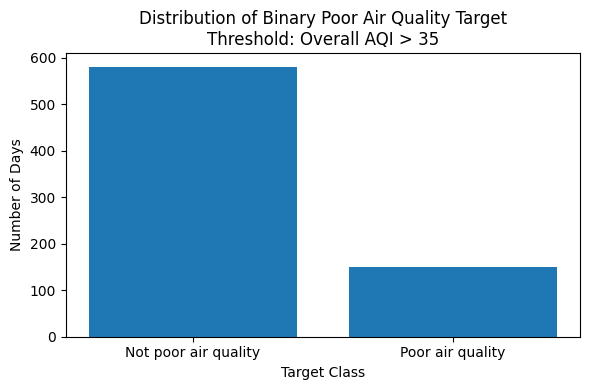

poor_air_quality
0    581
1    150
Name: count, dtype: int64
poor_air_quality
0    79.48
1    20.52
Name: count, dtype: float64


In [15]:
# Step 10: Plot target class distribution

target_counts = merged["poor_air_quality"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not poor air quality", "Poor air quality"], target_counts.values)
plt.title(f"Distribution of Binary Poor Air Quality Target\nThreshold: Overall AQI > {FINAL_AQI_THRESHOLD}")
plt.xlabel("Target Class")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

print(target_counts)
print((target_counts / len(merged) * 100).round(2))

# STEP 11: OVERALL AQI OVER TIME

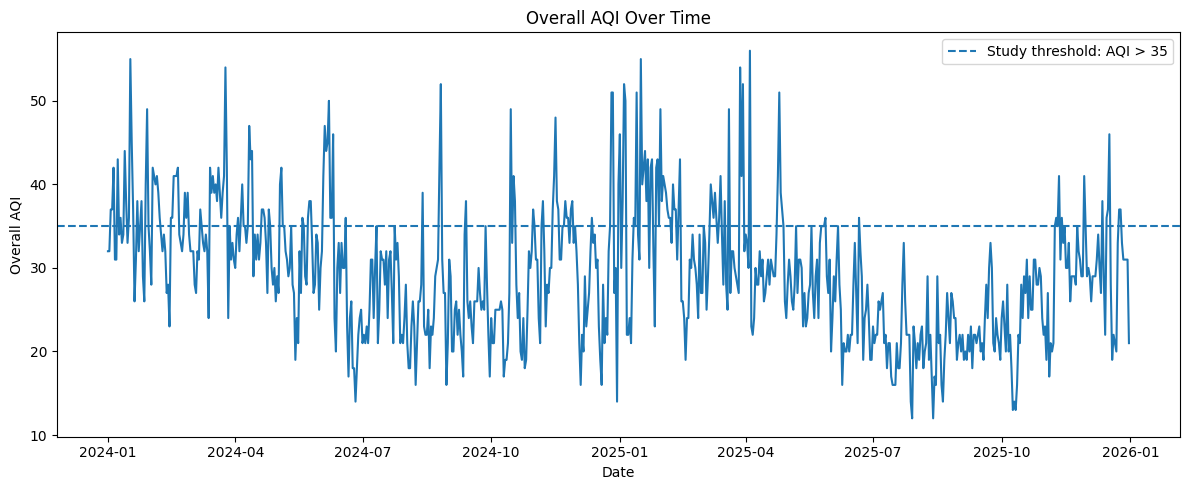

In [16]:
# Step 11: Plot overall AQI over time

plt.figure(figsize=(12, 5))
plt.plot(merged["date"], merged["overall_aqi"])
plt.axhline(
    y=FINAL_AQI_THRESHOLD,
    linestyle="--",
    label=f"Study threshold: AQI > {FINAL_AQI_THRESHOLD}"
)
plt.title("Overall AQI Over Time")
plt.xlabel("Date")
plt.ylabel("Overall AQI")
plt.legend()
plt.tight_layout()
plt.show()

# STEP 12: POLLUTANT SPECIFIC AQI VALUES OVER TIME

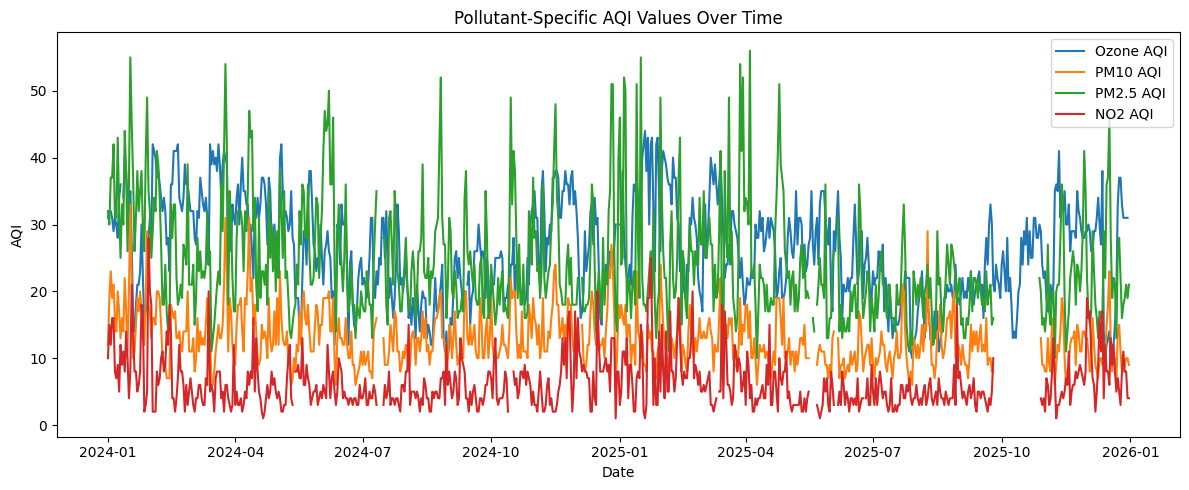

In [17]:
# Step 12: Plot pollutant-specific AQI values over time

plt.figure(figsize=(12, 5))
plt.plot(merged["date"], merged["daily_aqi_ozone"], label="Ozone AQI")
plt.plot(merged["date"], merged["daily_aqi_pm10"], label="PM10 AQI")
plt.plot(merged["date"], merged["daily_aqi_pm25"], label="PM2.5 AQI")
plt.plot(merged["date"], merged["daily_aqi_no2"], label="NO2 AQI")
plt.title("Pollutant-Specific AQI Values Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

# STEP 13: SEASONAL SUMMARY OF OVERALL AQI AND POOR AIR QUALITY DAYS

In [18]:
# Step 13: Seasonal summary of overall AQI and poor air quality days

season_summary = (
    merged
    .groupby("season")
    .agg(
        days=("date", "count"),
        mean_overall_aqi=("overall_aqi", "mean"),
        median_overall_aqi=("overall_aqi", "median"),
        max_overall_aqi=("overall_aqi", "max"),
        poor_air_quality_days=("poor_air_quality", "sum")
    )
    .round(2)
    .reset_index()
)

season_summary

,season,days,mean_overall_aqi,median_overall_aqi,max_overall_aqi,poor_air_quality_days
0,Fall,182,26.89,26.0,49.0,20
1,Spring,184,32.64,32.0,56.0,48
2,Summer,184,24.93,23.0,52.0,13
3,Winter,181,33.19,33.0,55.0,69


In [19]:
season_summary.to_csv("eda_season_summary.csv", index=False)
print("Saved: eda_season_summary.csv")

Saved: eda_season_summary.csv


# STEP 14: BOXPLOT OF OVERALL AQI BY SEASON

/tmp/ipykernel_14795/125916316.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_season, labels=season_order)


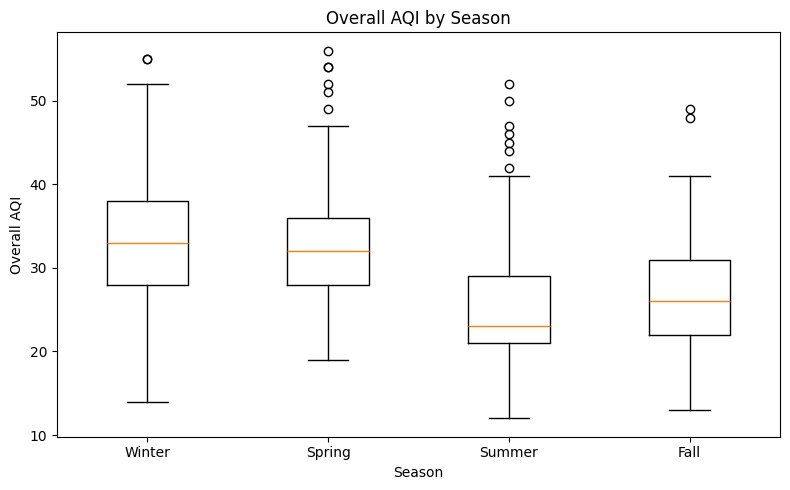

In [20]:
# Step 14: Boxplot of overall AQI by season

season_order = ["Winter", "Spring", "Summer", "Fall"]

data_by_season = [
    merged.loc[merged["season"] == season, "overall_aqi"].dropna()
    for season in season_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_season, labels=season_order)
plt.title("Overall AQI by Season")
plt.xlabel("Season")
plt.ylabel("Overall AQI")
plt.tight_layout()
plt.show()

# STEP 15: MONTHLY SUMMARY

In [21]:
# Step 15: Monthly summary

month_summary = (
    merged
    .groupby("month")
    .agg(
        days=("date", "count"),
        mean_overall_aqi=("overall_aqi", "mean"),
        median_overall_aqi=("overall_aqi", "median"),
        max_overall_aqi=("overall_aqi", "max"),
        poor_air_quality_days=("poor_air_quality", "sum")
    )
    .round(2)
    .reset_index()
)

month_summary

,month,days,mean_overall_aqi,median_overall_aqi,max_overall_aqi,poor_air_quality_days
0,1,62,36.82,36.0,55.0,33
1,2,57,33.79,34.0,43.0,26
2,3,62,34.89,34.0,54.0,26
3,4,60,32.92,32.0,56.0,15
4,5,62,30.11,29.0,42.0,7
5,6,60,27.40,25.5,50.0,10
6,7,62,24.13,22.5,35.0,0
7,8,62,23.35,22.0,52.0,3
8,9,60,23.88,22.5,38.0,1
9,10,62,25.18,25.0,49.0,4


In [22]:
month_summary.to_csv("eda_month_summary.csv", index=False)
print("Saved: eda_month_summary.csv")

Saved: eda_month_summary.csv


# STEP 16: CORRELATION OF PREDICTORS WITH OVERALL AQI

In [23]:
# Step 16: Correlation of predictors with overall AQI

corr_vars = [
    "overall_aqi",
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "awnd",
    "prcp",
    "tmax",
    "tmin"
]

correlation_with_aqi = (
    merged[corr_vars]
    .corr(numeric_only=True)["overall_aqi"]
    .sort_values(ascending=False)
    .round(3)
)

correlation_with_aqi

,overall_aqi
overall_aqi,1.000
daily_mean_pm25,0.686
daily_max_8hr_ozone,0.670
daily_mean_pm10,0.560
daily_max_1hr_no2,0.134
prcp,0.035
awnd,-0.007
tmin,-0.449
tmax,-0.492


In [24]:
correlation_with_aqi.to_csv("eda_correlation_with_overall_aqi.csv")
print("Saved: eda_correlation_with_overall_aqi.csv")

Saved: eda_correlation_with_overall_aqi.csv


# STEP 17: CORRELATION HEATMAP

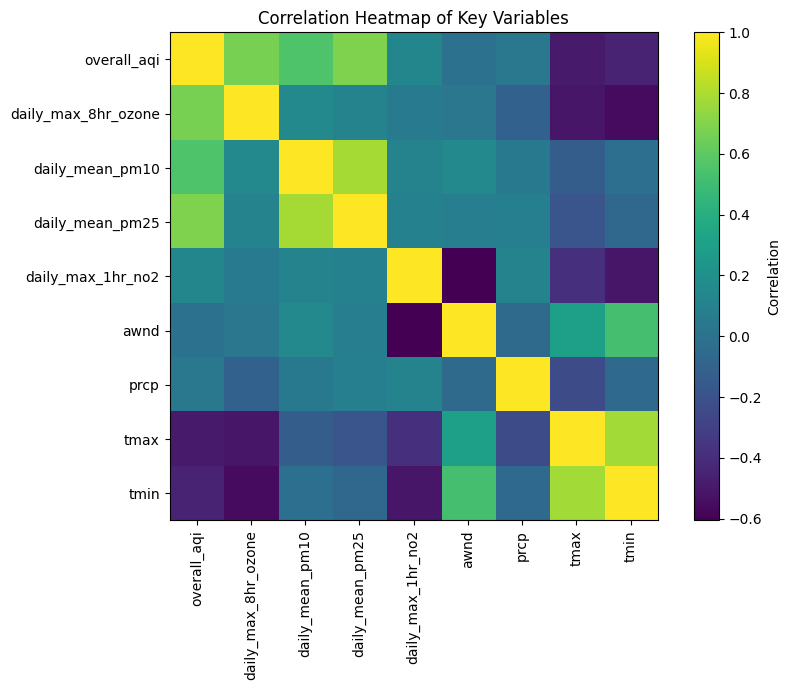

In [25]:
# Step 17: Correlation heatmap

corr_matrix = merged[corr_vars].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()
plt.show()

# STEP 18: SAVE UPDATED CLEANED DATASET WITH DOMINANT POLLUTANT

In [26]:
# Step 18: Save updated cleaned dataset with final target and dominant pollutant

print("Final target distribution before saving:")
print(merged["poor_air_quality"].value_counts().sort_index())

print("\nFinal target distribution (%):")
print((merged["poor_air_quality"].value_counts(normalize=True).sort_index() * 100).round(2))

merged.to_csv("aq_daily_merged_clean.csv", index=False)

print("\nSaved: aq_daily_merged_clean.csv")
print(f"Final target rule: poor_air_quality = 1 when overall_aqi > {FINAL_AQI_THRESHOLD}")

Final target distribution before saving:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Final target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64

Saved: aq_daily_merged_clean.csv
Final target rule: poor_air_quality = 1 when overall_aqi > 35


# STEP 19: CREATE FIGURES FOLDER

In [27]:
# Step 19: Create output folder for figures

from pathlib import Path

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {figures_dir}")

Figures will be saved to: outputs/figures


# STEP 20: SAVE TARGET DISTRIBUTION CHART

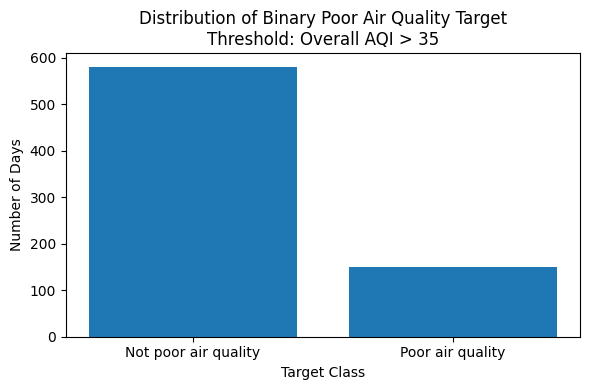

Saved: figure_01_target_distribution.png


In [28]:
# Step 20: Save target distribution chart

target_counts = merged["poor_air_quality"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Not poor air quality", "Poor air quality"], target_counts.values)
plt.title(f"Distribution of Binary Poor Air Quality Target\nThreshold: Overall AQI > {FINAL_AQI_THRESHOLD}")
plt.xlabel("Target Class")
plt.ylabel("Number of Days")
plt.tight_layout()

plt.savefig(figures_dir / "figure_01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_01_target_distribution.png")

# STEP 21: SAVE OVERALL AQI OVER TIME CHART

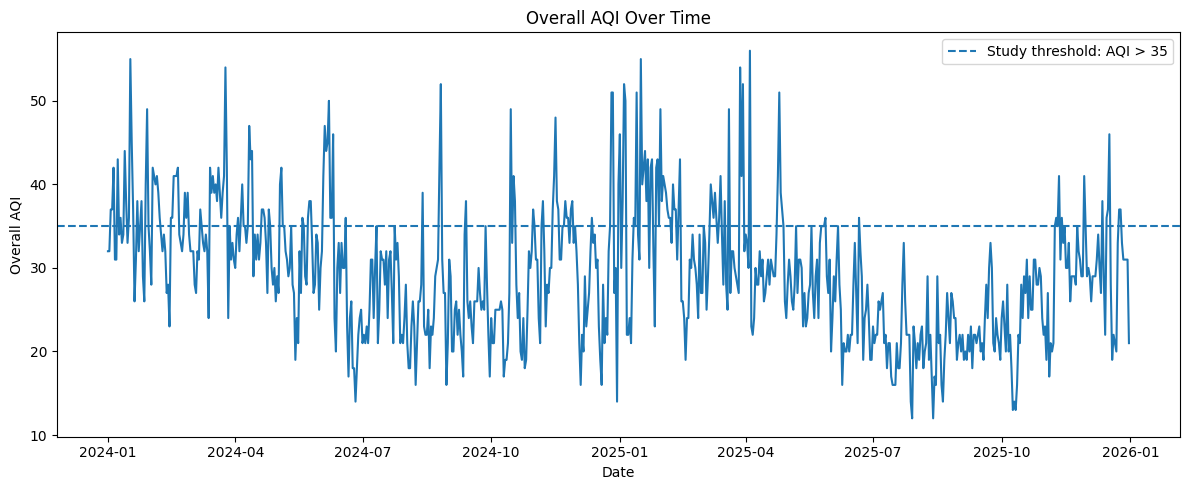

Saved: figure_02_overall_aqi_over_time.png


In [29]:
# Step 21: Save overall AQI over time chart

plt.figure(figsize=(12, 5))
plt.plot(merged["date"], merged["overall_aqi"])
plt.axhline(
    y=FINAL_AQI_THRESHOLD,
    linestyle="--",
    label=f"Study threshold: AQI > {FINAL_AQI_THRESHOLD}"
)
plt.title("Overall AQI Over Time")
plt.xlabel("Date")
plt.ylabel("Overall AQI")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "figure_02_overall_aqi_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_02_overall_aqi_over_time.png")

# STEP 22: SAVE POLLUTANT SPECIFIC AQI OVER TIME CHART

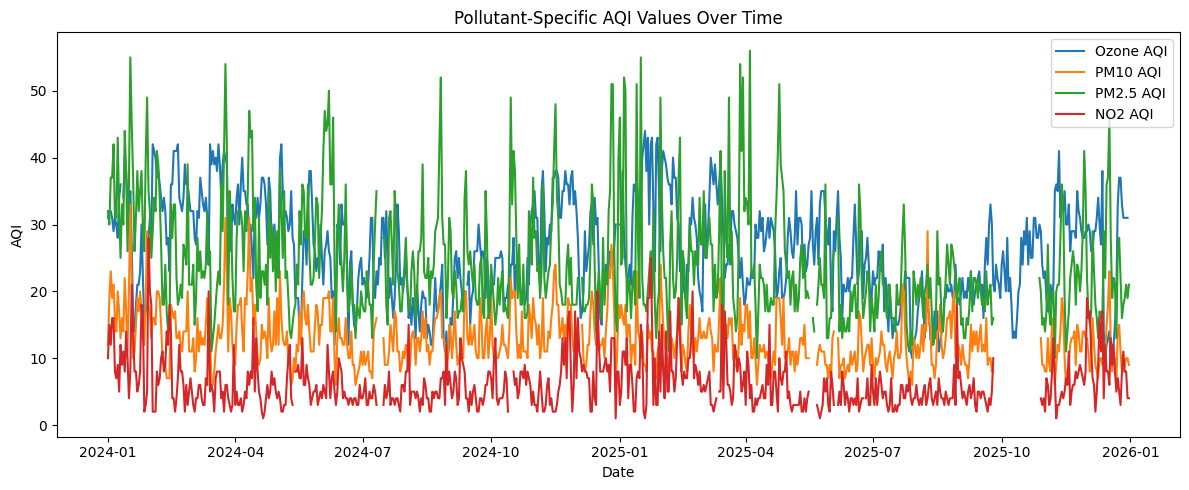

Saved: figure_03_pollutant_specific_aqi_over_time.png


In [30]:
# Step 22: Save pollutant-specific AQI over time chart

plt.figure(figsize=(12, 5))
plt.plot(merged["date"], merged["daily_aqi_ozone"], label="Ozone AQI")
plt.plot(merged["date"], merged["daily_aqi_pm10"], label="PM10 AQI")
plt.plot(merged["date"], merged["daily_aqi_pm25"], label="PM2.5 AQI")
plt.plot(merged["date"], merged["daily_aqi_no2"], label="NO2 AQI")
plt.title("Pollutant-Specific AQI Values Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "figure_03_pollutant_specific_aqi_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_03_pollutant_specific_aqi_over_time.png")

# STEP 23: SAVE SEASONAL AQI BOXPLOT

/tmp/ipykernel_14795/2445996187.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_season, labels=season_order)


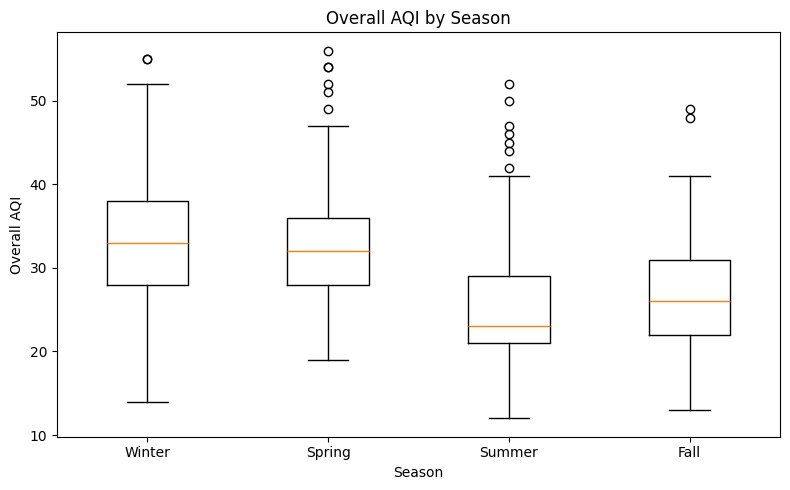

Saved: figure_04_overall_aqi_by_season.png


In [31]:
# Step 23: Save overall AQI by season boxplot

season_order = ["Winter", "Spring", "Summer", "Fall"]

data_by_season = [
    merged.loc[merged["season"] == season, "overall_aqi"].dropna()
    for season in season_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_season, labels=season_order)
plt.title("Overall AQI by Season")
plt.xlabel("Season")
plt.ylabel("Overall AQI")
plt.tight_layout()

plt.savefig(figures_dir / "figure_04_overall_aqi_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_04_overall_aqi_by_season.png")

# STEP 24: SAVE CORRELATION HEATMAP

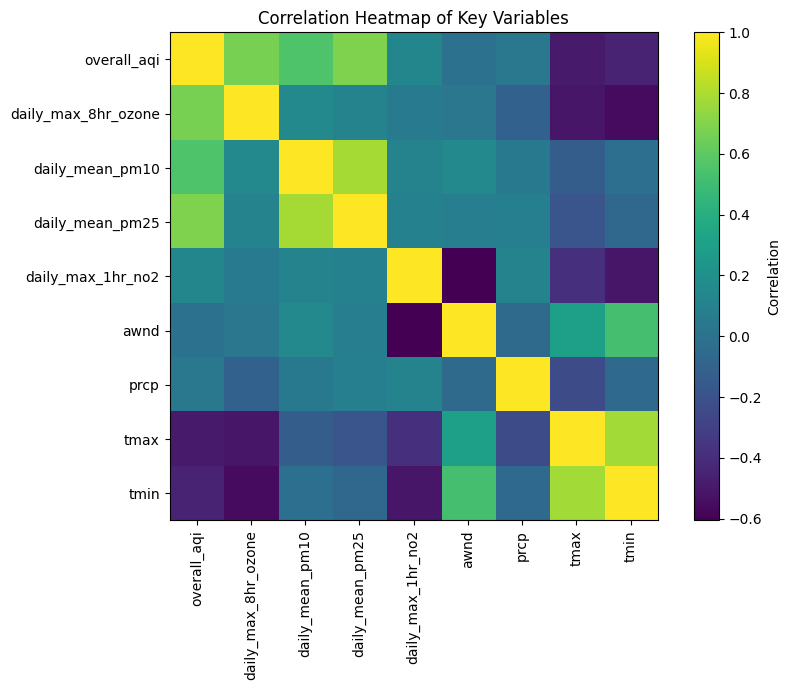

Saved: figure_05_correlation_heatmap.png


In [32]:
# Step 24: Save correlation heatmap

corr_vars = [
    "overall_aqi",
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "awnd",
    "prcp",
    "tmax",
    "tmin"
]

corr_matrix = merged[corr_vars].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Key Variables")
plt.tight_layout()

plt.savefig(figures_dir / "figure_05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_05_correlation_heatmap.png")

# STEP 25: ZIP AND DOWNLOAD FIGURES

In [33]:
# Step 25: Zip figures for download

import shutil
from google.colab import files

zip_path = "eda_figures.zip"

shutil.make_archive("eda_figures", "zip", figures_dir)

print(f"Created: {zip_path}")

files.download(zip_path)

Created: eda_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# FINAL EDA: REVIEW THRESHOLD SENSITIVITY

In [37]:
# Final EDA: Review threshold sensitivity for poor_air_quality

thresholds = [30, 35, 40, 45, 50]

threshold_review = []

for threshold in thresholds:
    target = (merged["overall_aqi"] > threshold).astype(int)
    counts = target.value_counts().sort_index()

    threshold_review.append({
        "threshold_rule": f"overall_aqi > {threshold}",
        "not_poor_days": counts.get(0, 0),
        "poor_days": counts.get(1, 0),
        "poor_days_percent": round((counts.get(1, 0) / len(merged)) * 100, 2),
        "selected_threshold": threshold == FINAL_AQI_THRESHOLD
    })

threshold_review = pd.DataFrame(threshold_review)

threshold_review.to_csv("eda_threshold_sensitivity_review.csv", index=False)

threshold_review

,threshold_rule,not_poor_days,poor_days,poor_days_percent,selected_threshold
0,overall_aqi > 30,414,317,43.37,False
1,overall_aqi > 35,581,150,20.52,True
2,overall_aqi > 40,668,63,8.62,False
3,overall_aqi > 45,707,24,3.28,False
4,overall_aqi > 50,719,12,1.64,False


# FINAL EDA: INSPECT FINAL POOR AIR QUALITY DAYS

In [38]:
# Final EDA: Inspect days classified as poor air quality under final study threshold

poor_days_final = merged.loc[
    merged["poor_air_quality"] == 1,
    [
        "date",
        "overall_aqi",
        "dominant_pollutant",
        "daily_aqi_ozone",
        "daily_aqi_pm10",
        "daily_aqi_pm25",
        "daily_aqi_no2",
        "tmax",
        "tmin",
        "prcp",
        "awnd",
        "season",
        "month"
    ]
].sort_values("date")

poor_days_final.to_csv("eda_poor_air_quality_days_final_threshold.csv", index=False)

print(f"Poor air quality days using final threshold overall_aqi > {FINAL_AQI_THRESHOLD}:")
print(poor_days_final.shape[0])

poor_days_final.head(20)

Poor air quality days using final threshold overall_aqi > 35:
150


,date,overall_aqi,dominant_pollutant,daily_aqi_ozone,daily_aqi_pm10,daily_aqi_pm25,daily_aqi_no2,tmax,tmin,prcp,awnd,season,month
2,2024-01-03,37.0,PM2.5,32.0,23.0,37.0,12.0,28.9,19.4,0.0,3.5,Winter,1
3,2024-01-04,37.0,PM2.5,31.0,19.0,37.0,16.0,26.7,19.4,0.0,2.4,Winter,1
4,2024-01-05,42.0,PM2.5,29.0,21.0,42.0,16.0,27.2,19.4,0.0,2.1,Winter,1
7,2024-01-08,43.0,PM2.5,28.0,20.0,43.0,9.0,24.4,20.0,60.5,6.9,Winter,1
9,2024-01-10,36.0,Ozone,36.0,13.0,25.0,12.0,25.6,16.7,0.0,3.0,Winter,1
12,2024-01-13,44.0,PM2.5,40.0,22.0,44.0,8.0,25.0,14.4,0.0,3.2,Winter,1
13,2024-01-14,38.0,Ozone,38.0,17.0,38.0,14.0,25.0,15.0,0.0,2.9,Winter,1
15,2024-01-16,36.0,PM2.5,32.0,20.0,36.0,4.0,26.7,21.7,0.3,6.4,Winter,1
16,2024-01-17,55.0,PM2.5,35.0,33.0,55.0,8.0,27.2,19.4,0.0,3.3,Winter,1
17,2024-01-18,45.0,PM2.5,27.0,21.0,45.0,21.0,26.1,17.2,0.0,1.2,Winter,1
